<a href="https://colab.research.google.com/github/Kaynan1101/AtvEletivaI/blob/main/processing_tracking_players.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Sun Mar  1 16:46:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   43C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install ultralytics roboflow supervision opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 50.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [3]:
!pip install roboflow

In [4]:
from google.colab import userdata
from roboflow import Roboflow
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("francisco-workspace").project("hockey-3fz5i")
version = project.version(7)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to hockey-7 in yolov8:: 100%|██████████| 7034/7034 [00:00<00:00, 7961.08it/s] 


In [6]:
model = YOLO("yolov8s.pt")

model.train(
    data="/content/hockey-7/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    cache=True
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/hockey-7/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79071f2104a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [84]:
from tqdm import tqdm
import supervision as sv
PLAYER_DETECTION_MODEL = YOLO("runs/detect/train/weights/best.pt")

SOURCE_VIDEO_PATH = "/content/play.mp4"
PLAYER_ID = 1
STRIDE = 30

frame_generator = sv.get_video_frames_generator(
    source_path=SOURCE_VIDEO_PATH, stride=STRIDE)

crops = []
for frame in tqdm(frame_generator, desc='collecting crops'):
    result = PLAYER_DETECTION_MODEL.predict(frame, conf=0.3)[0]
    detections = sv.Detections.from_ultralytics(result)
    detections = detections.with_nms(threshold=0.5, class_agnostic=True)
    detections = detections[detections.class_id == PLAYER_ID]
    players_crops = [sv.crop_image(frame, xyxy) for xyxy in detections.xyxy]
    crops += players_crops

collecting crops: 0it [00:00, ?it/s]


0: 384x640 2 goalkeepers, 6 players, 2 stick_blades, 8.0ms
Speed: 2.1ms preprocess, 8.0ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


collecting crops: 1it [00:00,  4.91it/s]


0: 384x640 2 goalkeepers, 7 players, 2 stick_blades, 8.2ms
Speed: 3.0ms preprocess, 8.2ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 goalkeepers, 7 players, 4 stick_blades, 8.1ms
Speed: 3.1ms preprocess, 8.1ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


collecting crops: 3it [00:00,  9.27it/s]

...

collecting crops: 69it [00:06, 12.02it/s]


0: 384x640 5 players, 2 stick_blades, 8.1ms
Speed: 3.1ms preprocess, 8.1ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 goalkeepers, 4 players, 3 stick_blades, 10.0ms
Speed: 3.3ms preprocess, 10.0ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


collecting crops: 71it [00:06, 11.58it/s]


0: 384x640 2 goalkeepers, 4 players, 1 puck, 2 stick_blades, 7.4ms
Speed: 2.8ms preprocess, 7.4ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


collecting crops: 72it [00:06, 11.11it/s]


In [91]:
import numpy as np
import cv2
from sklearn.cluster import KMeans
from collections import defaultdict

def is_referee(image):
    h, w = image.shape[:2]
    top = image[0:h//2, w//4:3*w//4]
    hsv = cv2.cvtColor(top, cv2.COLOR_BGR2HSV)
    low_sat = (hsv[:,:,1] < 40).sum()
    return low_sat / hsv[:,:,1].size > 0.75

def get_features(image):
    if image.size == 0:
        return np.zeros(2)
    h, w = image.shape[:2]
    torso = image[0:h//2, :]
    hsv = cv2.cvtColor(torso, cv2.COLOR_BGR2HSV)
    total = torso.shape[0] * torso.shape[1]

    # Edmonton: azul royal (cor exclusiva deles)
    blue = cv2.inRange(hsv, (100, 80, 60), (130, 255, 255))
    blue_ratio = blue.sum() / 255 / total

    # Edmonton: laranja
    orange = cv2.inRange(hsv, (8, 120, 120), (22, 255, 255))
    orange_ratio = orange.sum() / 255 / total

    edmonton_score = blue_ratio * 3 + orange_ratio * 2
    return np.array([edmonton_score, 1 - edmonton_score])


class TeamClassifier:
    """Classificador baseado em score de cor Edmonton vs Chicago.
    Não usa K-Means — compara diretamente contra threshold definido."""

    def __init__(self, threshold=0.05):
        self.threshold = threshold  # ajuste se necessário
        self.fitted = True

    def fit(self, crops):
        scores = [get_features(c)[0] for c in crops if not is_referee(c)]
        scores_sorted = sorted(scores)

        # Vale natural claramente em ~0.03 visto no histograma
        # Chicago: score < 0.03, Edmonton: score >= 0.03
        self.threshold = 0.05

        print(f"Threshold fixo: {self.threshold:.4f}")
        print(f"Edmonton (Time 0): {sum(1 for s in scores_sorted if s >= self.threshold)} crops")
        print(f"Chicago (Time 1): {sum(1 for s in scores_sorted if s < self.threshold)} crops")

    def predict(self, crops):
        results = []
        for c in crops:
            score = get_features(c)[0]
            # Score alto = Edmonton (Time 0), Score baixo = Chicago (Time 1)
            results.append(0 if score >= self.threshold else 1)
        return np.array(results)


class TeamTracker:
    """Mantém memória do time de cada jogador por tracker_id para reduzir oscilação."""
    def __init__(self, memory_size=10):
        self.history = defaultdict(list)
        self.memory_size = memory_size

    def update(self, tracker_ids, team_predictions):
        """Atualiza histórico e retorna predição suavizada por votação majoritária."""
        smoothed = []
        for tid, pred in zip(tracker_ids, team_predictions):
            self.history[tid].append(pred)
            # Mantém só os últimos N frames
            if len(self.history[tid]) > self.memory_size:
                self.history[tid] = self.history[tid][-self.memory_size:]
            # Voto majoritário
            votes = np.bincount(self.history[tid], minlength=2)
            smoothed.append(votes.argmax())
        return np.array(smoothed)

team_classifier = TeamClassifier()
team_classifier.fit(crops)
team_tracker = TeamTracker(memory_size=15)
print("Classificador treinado!")


Threshold fixo: 0.0500
Edmonton (Time 0): 149 crops
Chicago (Time 1): 84 crops
Classificador treinado!


In [92]:
def resolve_goalkeepers_team_id(players_detections, goalkeepers_detections):
    goalkeepers_xy = goalkeepers_detections.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
    players_xy = players_detections.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)

    team_ids = []
    for gk_xy in goalkeepers_xy:
        distances = {}
        for team_id in [0, 1]:
            team_mask = players_detections.class_id == team_id
            if team_mask.sum() == 0:
                distances[team_id] = float('inf')
                continue
            team_xy = players_xy[team_mask]
            dist = np.linalg.norm(team_xy - gk_xy, axis=1).mean()
            distances[team_id] = dist
        team_ids.append(min(distances, key=distances.get))

    return np.array(team_ids)


0: 384x640 2 goalkeepers, 4 players, 3 stick_blades, 7.8ms
Speed: 2.5ms preprocess, 7.8ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)
Jogador 0 → Time 0 | score=0.1402
Jogador 1 → Time 0 | score=0.1404
Jogador 2 → Time 0 | score=0.2697
Jogador 3 → Time 1 | score=0.0000


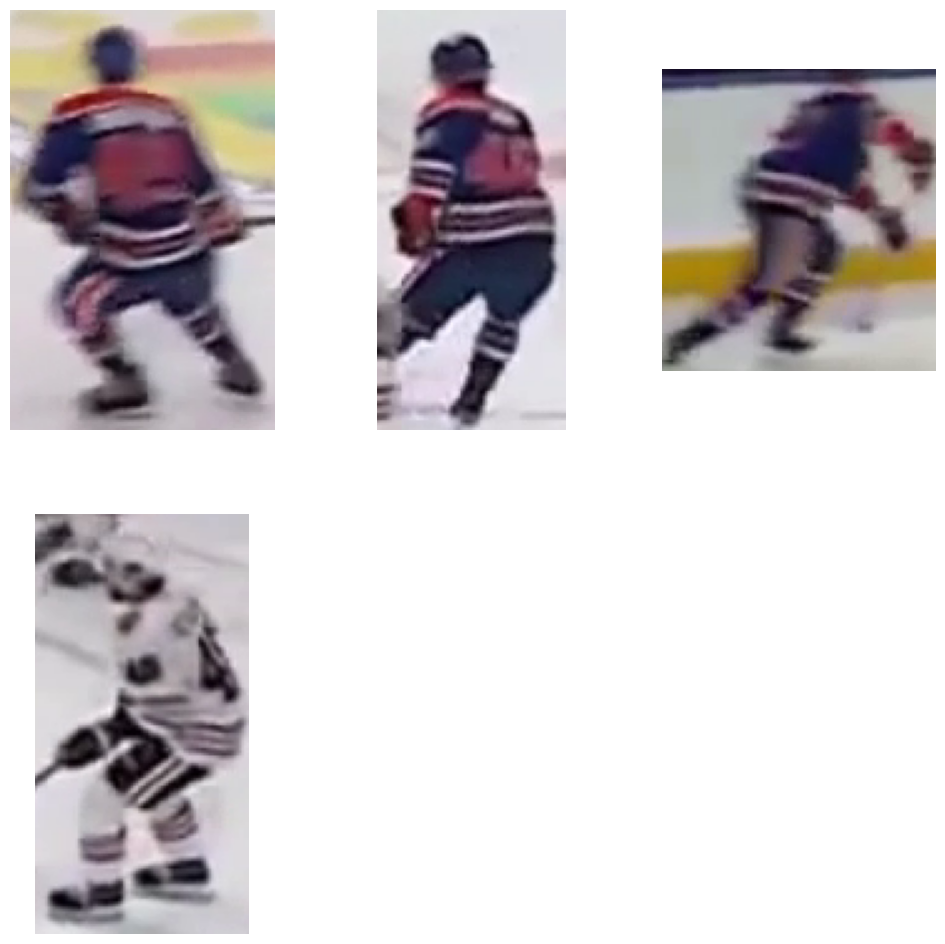

In [95]:
frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH, stride=100)
for i, frame in enumerate(frame_generator):
    if i == 5.5:  # pega um frame do meio do vídeo
        break

result = PLAYER_DETECTION_MODEL.predict(frame, conf=0.3)[0]
detections = sv.Detections.from_ultralytics(result)
detections = detections.with_nms(threshold=0.5, class_agnostic=True)
detections = detections[detections.class_id == PLAYER_ID]
crops_test = [sv.crop_image(frame, xyxy) for xyxy in detections.xyxy]
preds = team_classifier.predict(crops_test)

for i, (crop, pred) in enumerate(zip(crops_test, preds)):
    score = get_features(crop)[0]
    print(f"Jogador {i} → Time {pred} | score={score:.4f}")

sv.plot_images_grid(crops_test, grid_size=(2, len(crops_test)//2 + 1))

In [96]:
import supervision as sv
import numpy as np

SOURCE_VIDEO_PATH = "/content/play.mp4"
TARGET_VIDEO_PATH = "/content/output.avi"

GOALKEEPER_ID = 0
PLAYER_ID = 1

ellipse_annotator = sv.EllipseAnnotator(
    color=sv.ColorPalette.from_hex(['#FF6600', '#FFFFFF', '#FFD700']),
    thickness=2
)
label_annotator = sv.LabelAnnotator(
    color=sv.ColorPalette.from_hex(['#FF6600', '#FFFFFF', '#FFD700']),
    text_color=sv.Color.from_hex('#000000'),
    text_position=sv.Position.BOTTOM_CENTER
)

tracker = sv.ByteTrack()
tracker.reset()
team_tracker = TeamTracker(memory_size=15)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)

with sv.VideoSink(TARGET_VIDEO_PATH, video_info) as sink:
    for frame in tqdm(frame_generator, total=video_info.total_frames, desc="Processando vídeo"):

        result = PLAYER_DETECTION_MODEL.predict(frame, conf=0.3)[0]
        detections = sv.Detections.from_ultralytics(result)

        all_detections = detections.with_nms(threshold=0.5, class_agnostic=True)
        all_detections = all_detections[np.isin(all_detections.class_id, [GOALKEEPER_ID, PLAYER_ID])]
        all_detections = tracker.update_with_detections(detections=all_detections)

        goalkeepers_detections = all_detections[all_detections.class_id == GOALKEEPER_ID]
        players_detections = all_detections[all_detections.class_id == PLAYER_ID]

        # Classifica times com filtro de árbitro e suavização temporal
        if len(players_detections) > 0:
            players_crops = [sv.crop_image(frame, xyxy) for xyxy in players_detections.xyxy]

            # Identifica árbitros e remove das detecções de jogadores
            referee_mask = np.array([is_referee(c) for c in players_crops])

            valid_players = players_detections[~referee_mask]

            if len(valid_players) > 0:
                valid_crops = [c for c, is_ref in zip(players_crops, referee_mask) if not is_ref]
                raw_predictions = team_classifier.predict(valid_crops)
                # Suaviza com memória temporal
                smoothed_predictions = team_tracker.update(valid_players.tracker_id, raw_predictions)
                valid_players.class_id = smoothed_predictions

            players_detections = valid_players

        # Resolve goleiros
        if len(goalkeepers_detections) > 0 and len(players_detections) > 0:
            goalkeepers_detections.class_id = resolve_goalkeepers_team_id(
                players_detections, goalkeepers_detections)
        elif len(goalkeepers_detections) > 0:
            goalkeepers_detections.class_id = np.array([0] * len(goalkeepers_detections))

        all_detections = sv.Detections.merge([players_detections, goalkeepers_detections])

        labels = [f"#{tid}" for tid in all_detections.tracker_id]
        all_detections.class_id = all_detections.class_id.astype(int)

        annotated_frame = frame.copy()
        annotated_frame = ellipse_annotator.annotate(scene=annotated_frame, detections=all_detections)
        annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=all_detections, labels=labels)

        sink.write_frame(annotated_frame)

print("Vídeo salvo em:", TARGET_VIDEO_PATH)


Processando vídeo:   0%|          | 0/2137 [00:00<?, ?it/s]


0: 384x640 2 goalkeepers, 6 players, 2 stick_blades, 8.1ms
Speed: 3.0ms preprocess, 8.1ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)


Processando vídeo:   0%|          | 1/2137 [00:00<04:27,  7.97it/s]


0: 384x640 2 goalkeepers, 6 players, 2 stick_blades, 7.2ms
Speed: 2.2ms preprocess, 7.2ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 goalkeepers, 5 players, 2 stick_blades, 7.2ms
Speed: 2.2ms preprocess, 7.2ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 goalkeepers, 5 players, 2 stick_blades, 7.4ms
Speed: 2.2ms preprocess, 7.4ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


Processando vídeo:   0%|          | 4/2137 [00:00<01:59, 17.84it/s]

...


0: 384x640 1 goalkeeper, 4 players, 1 puck, 2 stick_blades, 9.0ms
Speed: 2.4ms preprocess, 9.0ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 goalkeepers, 5 players, 1 puck, 3 stick_blades, 7.5ms
Speed: 2.3ms preprocess, 7.5ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 goalkeepers, 3 players, 1 puck, 2 stick_blades, 7.4ms
Speed: 2.2ms preprocess, 7.4ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


Processando vídeo: 100%|█████████▉| 2134/2137 [01:27<00:00, 24.27it/s]


0: 384x640 2 goalkeepers, 4 players, 1 puck, 2 stick_blades, 7.2ms
Speed: 2.2ms preprocess, 7.2ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 goalkeepers, 3 players, 1 puck, 3 stick_blades, 7.1ms
Speed: 2.1ms preprocess, 7.1ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 goalkeepers, 3 players, 1 puck, 1 stick_blade, 7.1ms
Speed: 2.1ms preprocess, 7.1ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


Processando vídeo: 100%|██████████| 2137/2137 [01:27<00:00, 24.42it/s]

Vídeo salvo em: /content/output.avi
